# Integrated Gas-Solar Hybrid Asset Model — Nigeria
## A Three-Equation SUR System with Correlated Monte Carlo and Project Finance

**Profile:** BSc Geology | MSc Petroleum & Energy Engineering | MSc Financial Engineering | Solar experience

---

## The Analytical Argument

To optimise a gas-solar hybrid energy asset in Nigeria, three quantities must be modelled simultaneously and jointly:

1. **Gas supply price** — what it costs to fuel a gas thermal plant
2. **Gas thermal plant capacity factor** — how much of that plant actually runs
3. **Solar PV capacity factor** — how much the solar component generates

These are not independent. They share structural drivers: FX crises raise O&M costs for both technologies. Grid instability curtails both simultaneously, if solar connects to the National grid. Sector liquidity failures reduce offtake for both. When NLNG utilisation rises, domestic gas supply tightens and power output falls (Nigerias Domestic Gas Obligation Regulation tries to solve this) — while solar is unaffected but faces the same grid evacuation bottleneck.

Modelling them independently ignores this cross-equation error correlation. This notebook estimates all three equations jointly as a **Seemingly Unrelated Regression (SUR/FGLS)** system, simulates them jointly under a correlated stochastic framework, and feeds the joint outputs into a project finance waterfall to find the Sharpe-optimal gas-solar allocation and hedge ratio.

---

## Full Notebook Flow

```
PART 1 — FOUNDATIONS
  Cell 0:  Imports and configuration
  Cell 1:  Data assembly and variable catalogue (30+ variables, 8 categories)
  Cell 2:  Stationarity testing (ADF — every variable)
  Cell 3:  Cointegration testing (Engle-Granger — Equation 1)

PART 2 — THE THREE-EQUATION REGRESSION SYSTEM
  Cell 4:  Equation 1 — Gas price (OLS + NW-HAC SE)
  Cell 5:  Full regressor universe for Eq 2 and Eq 3
  Cell 6:  Multicollinearity audit (VIF — documenting the problem)
  Cell 7:  PCA factor reduction (solving multicollinearity — 20+ → orthogonal factors)
  Cell 8:  Equation 2 — Gas thermal CF (OLS on PCA factors + NW-HAC)
  Cell 9:  Equation 3 — Solar CF (OLS on PCA factors + NW-HAC)
  Cell 10: Cross-equation residual correlation test (SUR motivation)
  Cell 11: SUR estimation via FGLS (joint efficiency gain documented)

PART 3 — CORRELATED MONTE CARLO ENGINE
  Cell 12: Market driver covariance and Cholesky decomposition
  Cell 13: Joint path simulation (gas price, gas CF, solar CF from same factors)

PART 4 — PROJECT FINANCE
  Cell 14: Stochastic dispatch and project finance waterfall
  Cell 15: Risk metrics (P10/P50/P90, VaR, CVaR, DSCR)

PART 5 — PORTFOLIO AND HEDGE OPTIMISATION
  Cell 16: Sharpe-optimal gas-solar allocation
  Cell 17: Periodic hedge ratio optimisation

PART 6 — REAL DATA INTEGRATION
  Cell 18: Data pipeline (runnable with graceful fallback)
```

---

## Colour coding
- `# ── PLACEHOLDER ──` = synthetic data; real source documented
- `# ── SUR ──` = new jointly-estimated section
- `# ── FIX ──` = corrected from v1


---
# PART 1 — FOUNDATIONS
## Cell 0 — Imports and Configuration

In [1]:
# ══════════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# pip install pandas numpy matplotlib scipy scikit-learn
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F9F9F9',
    'axes.grid':True,'grid.alpha':0.25,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

START_DATE = '2015-01-01';  END_DATE  = '2025-12-31'
N_SIMS     = 5000;          N_MONTHS  = 120
RANDOM_SEED= 42;            np.random.seed(RANDOM_SEED)

print(f'Config: {N_SIMS:,} sims × {N_MONTHS} months | seed={RANDOM_SEED}')

Config: 5,000 sims × 120 months | seed=42


---
## Cell 1 — Data Assembly and Variable Catalogue

Every variable has a documented source. Synthetic series are flagged `# ── PLACEHOLDER ──` and will be updated as data becomes available.

### Variable catalogue by equation

**Equation 1 — Gas price drivers:**
`ln(brent)`, `ln(usdngn)`, `ln(demand_mw)`, `ttf_jkm`, `nlng_util`

**Equation 2 — Gas thermal CF drivers (8 categories, 20 variables):**

| Category | Variables |
|---|---|
| Gas supply | gas_to_power, domestic_alloc, gas_price (from Eq1), nlng_util, ttf_jkm |
| FX crisis | ln_usdngn, fx_reserves, inflation, receivables |
| LNG exports | jkm_netback |
| Pipeline vandalism | pipeline_down, vandalism_idx, fm_dummy |
| Maintenance | forced_outage, plant_age_gas, eaf |
| Policy | grid_demand_norm, dgso_dummy |
| Transmission | wheeling_cap, freq_collapse, tcn_curtailment |
| Sector liquidity | nbet_pay_ratio, disco_collect, market_shortfall |

**Equation 3 — Solar CF drivers (6 categories, 13 variables):**

| Category | Variables |
|---|---|
| Irradiance | ghi, dni |
| Temperature/season | temp_c, harmattan, precip_mm, aerosol_od |
| Grid evacuation | tcn_curtailment*, freq_collapse*, grid_voltage_dev |
| FX | ln_usdngn* |
| Sector liquidity | nbet_pay_ratio*, disco_collect* |
| Degradation | solar_plant_age |

*Shared with Equation 2 — creates cross-equation error correlation → SUR advantageous


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1
# Load reconstructed master panel
# No synthetic fallback required
# ═══════════════════════════════════════════════════════════════════════

import os
# Safety
_RANDOM_SEED = globals().get('RANDOM_SEED', 42)
_START_DATE  = globals().get('START_DATE', '2015-01-01')
_END_DATE    = globals().get('END_DATE', '2026-05-01')

RANDOM_SEED = _RANDOM_SEED
START_DATE  = _START_DATE
END_DATE    = _END_DATE

np.random.seed(RANDOM_SEED)

dates = pd.date_range(
    START_DATE,
    END_DATE,
    freq='MS'
)

# ──────────────────────────────────────────────────────────────
# LOAD RECONSTRUCTED PANEL
# ──────────────────────────────────────────────────────────────

PANEL_PATH = "data/master_panel_reconstructed_v2.csv"

if not os.path.exists(PANEL_PATH):
    raise FileNotFoundError(
        f"{PANEL_PATH} not found. "
        "Run reconstruction engine first."
    )

df = pd.read_csv(
    PANEL_PATH,
    index_col=0,
    parse_dates=True
)

df = df.reindex(dates).ffill().bfill()

# ──────────────────────────────────────────────────────────────
# VARIABLE ALIASES FOR BACKWARD COMPATIBILITY
# ──────────────────────────────────────────────────────────────

if "eaf" not in df.columns and "PAF" in df.columns:
    df["eaf"] = df["PAF"]

if "nbet_pay_ratio" not in df.columns and "nbet_mo_pay_ratio" in df.columns:
    df["nbet_pay_ratio"] = df["nbet_mo_pay_ratio"]

if "disco_collect" not in df.columns and "disco_collect_efficiency" in df.columns:
    df["disco_collect"] = df["disco_collect_efficiency"]


# ──────────────────────────────────────────────────────────────
# CANONICAL VARIABLE NAMES
# ──────────────────────────────────────────────────────────────

rename_map = {}

if "nbet_pay_ratio" in df.columns:
    rename_map["nbet_pay_ratio"] = "nbet_ratio"

if "Total_E_Rec_by_disco" in df.columns:
    rename_map["Total_E_Rec_by_disco"] = "receivables"

df = df.rename(columns=rename_map)

# Create standalone variables expected by old notebook cells

for col in df.columns:
    globals()[col] = df[col].values

In [4]:
df.columns

Index(['brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'ghi', 'dni', 'temp_c',
       'precip_mm', 'aerosol_od', 'fx_reserves', 'inflation', 'gas_price',
       'harmattan', 'fm_dummy', 'pipeline_down', 'vandalism_idx',
       'plant_age_gas', 'gas_to_power', 'domestic_alloc', 'eaf',
       'Transmission_Loss_factor', 'freq_collapse', 'load_variance', 'ATC&C',
       'Tech_&_commercial_loss', 'collection_loss', 'receivables',
       'Total_E_Billed_by_Disco', 'Total_E_paid_to_Disco', 'market_shortfall',
       'disco_collect', 'Billing_efficiency', 'nbet_ratio', 'gas_cf',
       'solar_cf', 'Gas_constraint', 'Distribution_constraint',
       'Transmission_constraint'],
      dtype='str')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DISTRIBUTION DIAGNOSTICS
# Review distributions before any outlier treatment
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Variables likely to contain operational outliers
review_vars = [

    # DEPENDENT VARIABLES
    'gas_price',
    'gas_cf',
    'solar_cf',

    # GAS MARKET
    'brent',
    'usdngn',
    'ttf_jkm',
    'jkm_netback',
    'inflation',
    'fx_reserves',

    # GAS CF DRIVERS
    'gas_to_power',
    'domestic_alloc',
    'eaf',
    'pipeline_down',

    # CONSTRAINTS
    'Gas_constraint',
    'Transmission_constraint',
    'Distribution_constraint',

    # POWER MARKET
    'market_shortfall',
    'ATC&C',
    'nbet_ratio',
    'freq_collapse',

    # SOLAR RESOURCE
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'harmattan'
]

available_vars = [v for v in review_vars if v in df.columns]

print("Variables found:")
print(available_vars)
    
for var in available_vars:

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    if len(s) < 10:
        continue

    print('\n' + '='*70)
    print(var)

    print(s.describe())

    print(f'Skewness: {s.skew():.2f}')
    print(f'Kurtosis: {s.kurtosis():.2f}')

    plt.figure(figsize=(8,4))
    plt.hist(s, bins=20)
    plt.title(f'{var} Distribution')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8,2))
    plt.boxplot(s, vert=False)
    plt.title(f'{var} Boxplot')
    plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# OUTLIER DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════

review_vars = [
    'solar_cf',
    'gas_cf',
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'nbet_ratio',
    'receivables'
]

for var in review_vars:

    if var not in df.columns:
        continue

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((s < lower) | (s > upper)).sum()

    print(
        f"{var:<15} "
        f"Outliers={outliers:>3} "
        f"({100*outliers/len(s):.1f}%)"
    )

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DESCRIPTIVE STATISTICS
# Review all variables in master dataframe
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns

desc_stats = pd.DataFrame(index=num_cols)

desc_stats['count'] = df[num_cols].count()
desc_stats['missing'] = df[num_cols].isna().sum()
desc_stats['mean'] = df[num_cols].mean()
desc_stats['median'] = df[num_cols].median()
desc_stats['std'] = df[num_cols].std()
desc_stats['min'] = df[num_cols].min()
desc_stats['max'] = df[num_cols].max()
desc_stats['skew'] = df[num_cols].skew()
desc_stats['kurtosis'] = df[num_cols].kurt()

# Round for readability
desc_stats = desc_stats.round(4)

print(desc_stats)

# Save for thesis documentation
desc_stats.to_csv('descriptive_statistics.csv')

print("\nSaved: descriptive_statistics.csv")
print(f"Variables analysed: {len(num_cols)}")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1B — CORRELATION DIAGNOSTICS
# Multicollinearity screening before econometric modelling
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Numeric variables only
num_df = df.select_dtypes(include=[np.number])

# Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Save full matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("=" * 80)
print("CORRELATION MATRIX SAVED")
print("=" * 80)

print(f"Variables analysed: {corr_matrix.shape[0]}")
print("Saved: correlation_matrix.csv")

# ------------------------------------------------------------
# High-correlation pairs
# ------------------------------------------------------------

threshold = 0.70

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i+1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Variable_1', 'Variable_2', 'Correlation']
)

high_corr_df = high_corr_df.sort_values(
    by='Correlation',
    key=lambda s: abs(s),
    ascending=False
)

print("\n" + "="*80)
print(f"HIGH CORRELATIONS (|ρ| ≥ {threshold})")
print("="*80)

print(high_corr_df)

high_corr_df.to_csv(
    'high_correlations.csv',
    index=False
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [ ]:
df.columns

In [ ]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
# ===========================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(df, variables, model_name):

    X = df[variables].copy()

    # remove rows with missing values
    X = X.dropna()

    # add intercept
    X = add_constant(X)

    vif_df = pd.DataFrame()

    vif_df["Variable"] = X.columns

    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    print(
        vif_df
        .sort_values("VIF", ascending=False)
        .round(2)
        .to_string(index=False)
    )

    return vif_df


# ============================================================
# GAS PRICE MODEL
# ============================================================

gas_price_vars = [
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]

compute_vif(
    df,
    gas_price_vars,
    "GAS PRICE MODEL"
)

# ===========================================================
# Receivables
# ===========================================================

receivables_vars = [
    "Total_E_Billed_by_Disco",
    "disco_collect",
    "nbet_ratio",
    "gas_cf"
]

compute_vif(
    df,
    receivables_vars, 
    "RECEIVABLES MODEL"
)


# ============================================================
# GAS CAPACITY FACTOR MODEL
# ============================================================

gas_cf_vars = [
    "eaf",
    "domestic_alloc",
    "gas_to_power",
    "pipeline_down",
    "vandalism_idx",
    "freq_collapse"
]

compute_vif(
    df,
    gas_cf_vars,
    "GAS CF MODEL"
)

# ============================================================
# EAF
# ============================================================

eaf_vars = [
    "gas_to_power",
    "vandalism_idx",
    "pipeline_down",
    "plant_age_gas",
    "freq_collapse"
]

compute_vif(
    df,
    eaf_vars,
    "EAF MODEL"
)

# ============================================================
# SOLAR CAPACITY FACTOR MODEL
# ============================================================

solar_cf_vars = [
    "dni",
    "harmattan",
    "precip_mm",
    "aerosol_od",
    "temp_c"
]

compute_vif(
    df,
    solar_cf_vars,
    "SOLAR CF MODEL"
)

---
## Cell 2 — Stationarity Testing (ADF + KPSS)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2 — STATIONARITY DIAGNOSTICS
# ADF + KPSS
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

stationarity_vars = {

    # GAS PRICE MODEL
    'gas_price'             : df['gas_price'],
    'brent'                 : df['brent'],
    'usdngn'                : df['usdngn'],
    'ttf_jkm'               : df['ttf_jkm'],
    'fx_reserves'           : df['fx_reserves'],
    'jkm_netback'           : df['jkm_netback'],

    # RECEIVABLES MODEL
    'ln_receivables'        : df['ln_receivables'],
    'nbet_ratio'            : df['nbet_ratio'],
    'disco_collect'         : df['disco_collect'],
    'gas_cf'                : df['gas_cf'],
    
    # EAF MODEL
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'gas_to_power'          : df['gas_to_power'],
    'plant_age_gas'         : df['plant_age_gas'],
    'freq_collapse'         : df['freq_collapse'],

     # GAS CF MODEL
    'gas_cf'                : df['gas_cf'],
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'freq_collapse'         : df['freq_collapse'],    
    'domestic_alloc'        : df['domestic_alloc'],

    # SOLAR CF MODEL
    'solar_cf'              : df['solar_cf'],
    'dni'                   : df['dni'],
    'precip_mm'             : df['precip_mm'],
    'harmattan'             : df['harmattan'],
    'aerosol_od'            : df['aerosol_od'],
    'temp_c'                : df['temp_c']
}

results = []

for name, series in stationarity_vars.items():

    s = pd.Series(series).dropna()

    try:

        adf_p = adfuller(
            s,
            autolag='AIC'
        )[1]

        kpss_p = kpss(
            s,
            regression='ct',
            nlags='auto'
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:
            verdict = 'I(0)'
            action = 'LEVEL'

        elif adf_p > 0.05 and kpss_p < 0.05:
            verdict = 'I(1)'
            action = 'DIFFERENCE'

        else:
            verdict = 'Ambiguous'
            action = 'CHECK'

        results.append([
            name,
            round(adf_p,4),
            round(kpss_p,4),
            verdict,
            action
        ])

    except Exception as ex:

        results.append([
            name,
            np.nan,
            np.nan,
            f'Error: {ex}'
        ])

stationarity_results = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'ADF_p',
        'KPSS_p',
        'Conclusion',
        'Action'
    ]
)
print("\nSUMMARY")
print(
    stationarity_results["Conclusion"]
    .value_counts()
)
print(stationarity_results)

stationarity_results.to_csv(
    'stationarity_results.csv',
    index=False
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1B — CORRELATION DIAGNOSTICS
# Multicollinearity screening before econometric modelling
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Numeric variables only
num_df = df.select_dtypes(include=[np.number])

# Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Save full matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("=" * 80)
print("CORRELATION MATRIX SAVED")
print("=" * 80)

print(f"Variables analysed: {corr_matrix.shape[0]}")
print("Saved: correlation_matrix.csv")

# ------------------------------------------------------------
# High-correlation pairs
# ------------------------------------------------------------

threshold = 0.70

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i+1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Variable_1', 'Variable_2', 'Correlation']
)

high_corr_df = high_corr_df.sort_values(
    by='Correlation',
    key=lambda s: abs(s),
    ascending=False
)

print("\n" + "="*80)
print(f"HIGH CORRELATIONS (|ρ| ≥ {threshold})")
print("="*80)

print(high_corr_df)

high_corr_df.to_csv(
    'high_correlations.csv',
    index=False
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2B — RESOLVE AMBIGUOUS STATIONARITY RESULTS
# KPSS (LEVEL STATIONARITY)
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

ambiguous_vars = stationarity_results.loc[
    stationarity_results["Conclusion"] == "Ambiguous",
    "Variable"
].tolist()

results_2b = []

for var in ambiguous_vars:

    s = df[var].dropna()

    try:

        adf_p = adfuller(
            s,
            autolag="AIC"
        )[1]

        kpss_p = kpss(
            s,
            regression="c",
            nlags="auto"
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:

            verdict = "I(0)"
            action = "LEVEL"

        elif adf_p > 0.05 and kpss_p < 0.05:

            verdict = "I(1)"
            action = "DIFFERENCE"

        else:

            verdict = "Still Ambiguous"
            action = "VISUAL_CHECK"

        results_2b.append([
            var,
            round(adf_p, 4),
            round(kpss_p, 4),
            verdict,
            action
        ])

    except Exception as ex:

        results_2b.append([
            var,
            np.nan,
            np.nan,
            f"Error: {ex}",
            "CHECK"
        ])

cell2b_results = pd.DataFrame(
    results_2b,
    columns=[
        "Variable",
        "ADF_p",
        "KPSS_c_p",
        "Conclusion",
        "Action"
    ]
)

print("\nCELL 2B RESULTS")
print(cell2b_results)

print("\nSUMMARY")
print(cell2b_results["Conclusion"].value_counts())

cell2b_results.to_csv(
    "stationarity_results_cell2b.csv",
    index=False
)

---
# PART 2 MODELS

## Cell 3 — GAS PRICE

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — ARDL BOUNDS TEST (GAS PRICE MODEL)
# FIXED ECONOMIC SPECIFICATION
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.ardl import UECM

# --------------------------------------------------
# DATA
# --------------------------------------------------

ardl_df = df[[
    "gas_price",
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]].dropna()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

ardl_df["ln_gas_price"] = np.log(ardl_df["gas_price"])

ardl_df["ln_usdngn"] = np.log(
    np.clip(ardl_df["usdngn"], 1e-6, None)
)

ardl_df["ln_brent"] = np.log(
    np.clip(ardl_df["brent"], 1e-6, None)
)

ardl_df["ln_fx"] = np.log(
    np.clip(ardl_df["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = ardl_df["ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = ardl_df[
    [
        "ln_usdngn",
        "ln_brent",
        "ttf_jkm",
        "jkm_netback",
        "ln_fx"
    ]
]

# --------------------------------------------------
# FIXED ARDL(1,1,1,1,1,1)
# --------------------------------------------------

ardl_model = ARDL(
    endog=y,
    lags=1,
    exog=X,
    order=1,
    trend="c"
)

ardl_res = ardl_model.fit()

print("=" * 70)
print("GAS PRICE ARDL RESULTS")
print("=" * 70)

print(ardl_res.summary())

# --------------------------------------------------
# UECM REPRESENTATION
# --------------------------------------------------

uecm = UECM.from_ardl(ardl_model)

uecm_res = uecm.fit()

print("\n")
print("=" * 70)
print("UECM RESULTS")
print("=" * 70)

print(uecm_res.summary())

# --------------------------------------------------
# BOUNDS TEST
# --------------------------------------------------

bounds = uecm_res.bounds_test(case=3)

print("\n")
print("=" * 70)
print("BOUNDS TEST")
print("=" * 70)

print(bounds)

print("\nF-STATISTIC:")
print(bounds.stat)

# --------------------------------------------------
# INTERPRETATION
# --------------------------------------------------

print("\n")
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("Null Hypothesis: No Cointegration")

if bounds.stat > 5:
    print("\nStrong evidence of cointegration.")

elif bounds.stat > 3:
    print("\nPossible cointegration. Check critical values.")

else:
    print("\nLittle evidence of cointegration.")

# --------------------------------------------------
# ERROR CORRECTION TERM
# --------------------------------------------------

if "ci_summary" in dir(uecm_res):

    print("\n")
    print("=" * 70)
    print("LONG-RUN RELATIONSHIP")
    print("=" * 70)

    print(uecm_res.ci_summary())

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 — GAS PRICE MODEL
# SHORT-RUN DIFFERENCED REGRESSION
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm

# --------------------------------------------------
# BUILD REGRESSION DATASET
# --------------------------------------------------

gp = df[
    [
        "gas_price",
        "usdngn",
        "brent",
        "ttf_jkm",
        "jkm_netback",
        "fx_reserves"
    ]
].copy()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

gp["ln_gas_price"] = np.log(
    np.clip(gp["gas_price"], 1e-6, None)
)

gp["ln_usdngn"] = np.log(
    np.clip(gp["usdngn"], 1e-6, None)
)

gp["ln_brent"] = np.log(
    np.clip(gp["brent"], 1e-6, None)
)

gp["ln_fx"] = np.log(
    np.clip(gp["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# FIRST DIFFERENCES
# --------------------------------------------------

gp["d_ln_gas_price"] = gp["ln_gas_price"].diff()

gp["d_ln_usdngn"] = gp["ln_usdngn"].diff()

gp["d_ln_brent"] = gp["ln_brent"].diff()

gp["d_ln_fx"] = gp["ln_fx"].diff()

gp["d_ttf_jkm"] = gp["ttf_jkm"].diff()

gp["d_jkm_netback"] = gp["jkm_netback"].diff()

gp = gp.dropna()

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = gp["d_ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = gp[
    [
        "d_ln_usdngn",
        "d_ln_brent",
        "d_ttf_jkm",
        "d_jkm_netback",
        "d_ln_fx"
    ]
]

X = sm.add_constant(X)

# --------------------------------------------------
# OLS + NEWEY-WEST HAC
# --------------------------------------------------

model = sm.OLS(y, X)

results = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------

print("=" * 80)
print("GAS PRICE MODEL")
print("SHORT-RUN DIFFERENCED REGRESSION")
print("=" * 80)

print(results.summary())

# --------------------------------------------------
# DIAGNOSTICS
# --------------------------------------------------

print("\n")
print("=" * 80)
print("KEY METRICS")
print("=" * 80)

print(f"Observations : {int(results.nobs)}")
print(f"R²           : {results.rsquared:.4f}")
print(f"Adj. R²      : {results.rsquared_adj:.4f}")
print(f"AIC          : {results.aic:.4f}")
print(f"BIC          : {results.bic:.4f}")

# --------------------------------------------------
# ECONOMIC INTERPRETATION TABLE
# --------------------------------------------------

coef_table = pd.DataFrame({
    "Coefficient": results.params,
    "Std_Error": results.bse,
    "t_stat": results.tvalues,
    "p_value": results.pvalues
})

print("\n")
print("=" * 80)
print("COEFFICIENTS")
print("=" * 80)

print(coef_table.round(4))

---
## EAF MODEL

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# EAF DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

eaf_vars = [
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'plant_age_gas',
    'gas_to_power',
    'freq_collapse'
]

eaf_df = df[eaf_vars].copy()

# -------------------------------------------------------------
# 1. EAF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("EAF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {eaf_df['eaf'].mean():.4f}")
print(f"Min  : {eaf_df['eaf'].min():.4f}")
print(f"Max  : {eaf_df['eaf'].max():.4f}")
print(f"Std  : {eaf_df['eaf'].std():.4f}")

print("\nFull Summary")
print(eaf_df['eaf'].describe())

# -------------------------------------------------------------
# 2. EAF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    eaf_df['eaf'],
    linewidth=2
)

plt.title("Equivalent Availability Factor (EAF)")
plt.xlabel("Date")
plt.ylabel("EAF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. EAF CORRELATION MATRIX
# -------------------------------------------------------------

corr_matrix = eaf_df.corr()

print("\n" + "="*70)
print("EAF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("EAF Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — EAF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["eaf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "plant_age_gas",
        "gas_to_power",
        "freq_collapse"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel.model.ardl_order)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

ardl_model = sel.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(ardl_model.summary())

The full EAF ARDL MODEL doesn't perform better than the AIC-selceted specification above, i'll keep the later.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# EAF ARDL (AGE REMOVED, TREND INCLUDED)
# ═══════════════════════════════════════════════════════════════════════
y = df["eaf"]

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "gas_to_power",
        "freq_collapse"
    ]
]

sel2 = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="ct"
)

print("\nSELECTED ORDER")
print(sel2.model.ardl_order)

print("\nAR LAGS")
print(sel2.model.ar_lags)

print("\nDL LAGS")
print(sel2.model.dl_lags)

eaf_model_2 = sel2.model.fit()

print(eaf_model_2.summary())

In [ ]:
from statsmodels.tsa.ardl import UECM

forced_uecm = UECM.from_ardl(forced_eaf.model)

forced_uecm_res = forced_uecm.fit()

print(forced_uecm_res.summary())

In [ ]:
forced_bt = forced_uecm_res.bounds_test(case=5)

print(forced_bt)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# FORCED EAF MODEL
# Keep all engineering variables regardless of AIC selection
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

forced_eaf = ARDL(
    endog=df["eaf"],
    lags=1,
    exog=df[
        [
            "pipeline_down",
            "vandalism_idx",
            "gas_to_power",
            "freq_collapse"
        ]
    ],
    order=1,
    trend="ct"
).fit()

print("\n" + "="*70)
print("FORCED EAF MODEL")
print("="*70)

print(forced_eaf.summary())

Pipeline downtime, vandalism incidents, and gas-to-power allocation were initially included based on engineering considerations. However, when forced into the ARDL specification, these variables remained statistically insignificant and materially worsened model fit (higher AIC). Consequently, the final EAF specification retained only the statistically supported variables identified through ARDL lag selection.

---
## GAS CF MODEL

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

gas_cf_vars = [
    'gas_cf',
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'domestic_alloc',
    'freq_collapse'
]

gas_cf_df = df[gas_cf_vars].copy()

# -------------------------------------------------------------
# 1. GAS CF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("GAS CF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {gas_cf_df['gas_cf'].mean():.4f}")
print(f"Min  : {gas_cf_df['gas_cf'].min():.4f}")
print(f"Max  : {gas_cf_df['gas_cf'].max():.4f}")
print(f"Std  : {gas_cf_df['gas_cf'].std():.4f}")

print("\nFull Summary")
print(gas_cf_df['gas_cf'].describe())

# -------------------------------------------------------------
# 2. GAS CF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    gas_cf_df['gas_cf'],
    linewidth=2
)

plt.title("Gas Capacity Factor (GAS CF)")
plt.xlabel("Date")
plt.ylabel("GAS CF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. GAS CF CORRELATION MATRIX
# -------------------------------------------------------------

corr_matrix = gas_cf_df.corr()

print("\n" + "="*70)
print("GAS CF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("GAS CF Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — GAS CF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["gas_cf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "eaf",
        "pipeline_down",
        "vandalism_idx",
        "freq_collapse",
        "domestic_alloc"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel_gcf = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel_gcf.model.ardl_order)

print("\nAR LAGS")
print(sel_gcf.model.ar_lags)

print("\nDL LAGS")
print(sel_gcf.model.dl_lags)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

gcf_model = sel_gcf.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(gcf_model.summary())

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF ARDL FOR UECM / BOUNDS TEST
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

gcf_ardl_ecm = ARDL(
    endog=df["gas_cf"],
    lags=1,
    exog=df[
        [
            "vandalism_idx",
            "freq_collapse",
            "domestic_alloc"
        ]
    ],
    order=1,          # force lag 1 on every variable
    trend="c"
).fit()

print(gcf_ardl_ecm.summary())

In [ ]:
from statsmodels.tsa.ardl import UECM

gcf_uecm = UECM.from_ardl(gcf_ardl_ecm.model)

gcf_uecm_res = gcf_uecm.fit()

print(gcf_uecm_res.summary())

In [ ]:
gcf_bt = gcf_uecm_res.bounds_test(case=3)

print(gcf_bt)

In [ ]:
print(gcf_uecm_res.test_serial_correlation())
print(gcf_uecm_res.test_heteroskedasticity())
print(gcf_uecm_res.test_normality())

Empirical evidence suggests that system instability indicators exhibited greater explanatory power for Gas Capacity Factor than the expected fuel-supply and availability indicators over the study period.

ARCH-LM tests indicated heteroskedasticity in the residuals of the EAF and Gas CF equations. Given the forecasting orientation of the study and the stability of the key ECM coefficients, the models were retained while interpreting marginal coefficient significance with caution.

---
## Receivables Model

In [5]:
df['receivables'].describe()

count    1.320000e+02
mean     2.023376e+11
std      2.306087e+11
min      5.312900e+10
25%      1.172500e+11
50%      1.520000e+11
75%      1.532500e+11
max      9.690000e+11
Name: receivables, dtype: float64

In [6]:
df["ln_receivables"] = np.log(df["receivables"])

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — RECEIVABLES CORRELATION ANALYSIS
# Pearson + Spearman
# ═══════════════════════════════════════════════════════════════════════

recv_vars = [
    'ln_receivables',
    'nbet_ratio',
    'disco_collect',
    'gas_cf'
]

recv_df = df[recv_vars].copy()

print("="*70)
print("PEARSON CORRELATION")
print("="*70)

pearson_corr = recv_df.corr(method='pearson')
print(pearson_corr)

print("\n")

print("="*70)
print("SPEARMAN CORRELATION")
print("="*70)

spearman_corr = recv_df.corr(method='spearman')
print(spearman_corr)

PEARSON CORRELATION
                ln_receivables  nbet_ratio  disco_collect    gas_cf
ln_receivables        1.000000    0.725261       0.510051 -0.196561
nbet_ratio            0.725261    1.000000       0.841536  0.195200
disco_collect         0.510051    0.841536       1.000000  0.311247
gas_cf               -0.196561    0.195200       0.311247  1.000000


SPEARMAN CORRELATION
                ln_receivables  nbet_ratio  disco_collect    gas_cf
ln_receivables        1.000000    0.727557       0.407304 -0.222995
nbet_ratio            0.727557    1.000000       0.753483  0.077540
disco_collect         0.407304    0.753483       1.000000  0.334655
gas_cf               -0.222995    0.077540       0.334655  1.000000


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4A — ARDL LAG SELECTION
# ln_receivables
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

y = df["ln_receivables"]

X = df[
    [
        "nbet_ratio",
        "disco_collect",
        "gas_cf"
    ]
]

sel_recv = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\nSELECTED ORDER")
print(sel_recv.model.ardl_order)

print("\nAR LAGS")
print(sel_recv.model.ar_lags)

print("\nDL LAGS")
print(sel_recv.model.dl_lags)


SELECTED ORDER
(1, 0, 1)

AR LAGS
[1]

DL LAGS
{'nbet_ratio': [0], 'disco_collect': [0, 1]}


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4B — ARDL ESTIMATION
# ═══════════════════════════════════════════════════════════════════════

recv_ardl = sel_recv.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(recv_ardl.summary())


ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:         ln_receivables   No. Observations:                  132
Model:                  ARDL(1, 0, 1)   Log Likelihood                  66.399
Method:               Conditional MLE   S.D. of innovations              0.146
Date:                Sat, 06 Jun 2026   AIC                           -120.797
Time:                        22:13:21   BIC                           -103.546
Sample:                    02-01-2015   HQIC                          -113.787
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.0427      0.772      1.350      0.180      -0.486       2.571
ln_receivables.L1     0.9543      0.028     34.043      0.000       0.899       1.010
nbet_ratio

In [11]:
# ═══════════════════════════════════════════════════════════════
# RECEIVABLES ECM-COMPATIBLE ARDL
# ═══════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

recv_ardl_ecm = ARDL(
    endog=df["ln_receivables"],
    lags=1,
    exog=df[
        [
            "nbet_ratio",
            "disco_collect"
        ]
    ],
    order=1,
    trend="c"
).fit()

print(recv_ardl_ecm.summary())

                              ARDL Model Results                              
Dep. Variable:         ln_receivables   No. Observations:                  132
Model:                  ARDL(1, 1, 1)   Log Likelihood                  66.500
Method:               Conditional MLE   S.D. of innovations              0.146
Date:                Sat, 06 Jun 2026   AIC                           -119.001
Time:                        22:25:39   BIC                            -98.874
Sample:                    02-01-2015   HQIC                          -110.823
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9418      0.808      1.165      0.246      -0.657       2.541
ln_receivables.L1     0.9575      0.029     32.944      0.000       0.900       1.015
nbet_ratio.L0         0.

In [12]:
from statsmodels.tsa.ardl import UECM

recv_uecm = UECM.from_ardl(recv_ardl_ecm.model)

recv_uecm_res = recv_uecm.fit()

print(recv_uecm_res.summary())

                              UECM Model Results                              
Dep. Variable:       D.ln_receivables   No. Observations:                  132
Model:                  UECM(1, 1, 1)   Log Likelihood                  66.500
Method:               Conditional MLE   S.D. of innovations             25.701
Date:                Sat, 06 Jun 2026   AIC                           -119.001
Time:                        22:26:13   BIC                            -98.874
Sample:                    02-01-2015   HQIC                          -110.823
                         - 12-01-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.9418      0.808      1.165      0.246      -0.657       2.541
ln_receivables.L1     -0.0425      0.029     -1.462      0.146      -0.100       0.015
nbet_ratio.L1       

In [13]:
recv_bt = recv_uecm_res.bounds_test(case=3)

print(recv_bt)

BoundsTestResult
Stat: 2.18010
Upper P-value: 0.47
Lower P-value: 0.204
Null: No Cointegration
Alternative: Possible Cointegration



---
## Solar CF


SOLAR CF DESCRIPTIVE STATISTICS
Mean : 16.7614
Min  : 12.5000
Max  : 23.0000
Std  : 3.2412

Full Summary
count    132.000000
mean      16.761364
std        3.241234
min       12.500000
25%       13.500000
50%       16.250000
75%       19.000000
max       23.000000
Name: solar_cf, dtype: float64


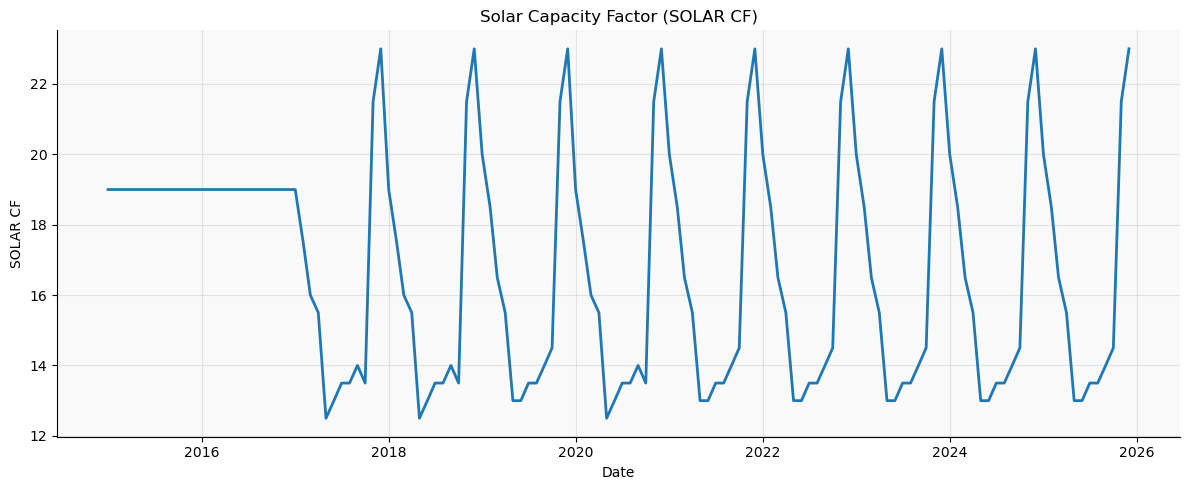

PEARSON CORRELATION
            solar_cf       dni  precip_mm  harmattan  aerosol_od    temp_c
solar_cf    1.000000  0.847770  -0.744785   0.880579    0.076594 -0.083846
dni         0.847770  1.000000  -0.725891   0.717488   -0.168905  0.049323
precip_mm  -0.744785 -0.725891   1.000000  -0.791165   -0.352891 -0.314864
harmattan   0.880579  0.717488  -0.791165   1.000000    0.366327  0.061090
aerosol_od  0.076594 -0.168905  -0.352891   0.366327    1.000000  0.369481
temp_c     -0.083846  0.049323  -0.314864   0.061090    0.369481  1.000000


SPEARMAN CORRELATION
            solar_cf       dni  precip_mm  harmattan  aerosol_od    temp_c
solar_cf    1.000000  0.832646  -0.818978   0.872016    0.121625 -0.043161
dni         0.832646  1.000000  -0.777433   0.757073   -0.039725  0.129485
precip_mm  -0.818978 -0.777433   1.000000  -0.869534   -0.385385 -0.163125
harmattan   0.872016  0.757073  -0.869534   1.000000    0.368096  0.106244
aerosol_od  0.121625 -0.039725  -0.385385   0.368096    1

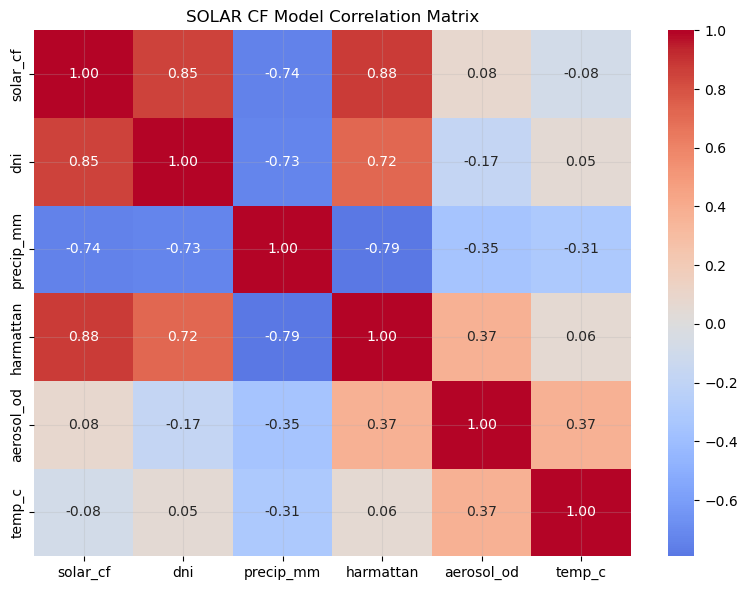

In [15]:
# ═══════════════════════════════════════════════════════════════════════
# SOLAR CF MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

solar_cf_vars = [
    'solar_cf',
    'dni',
    'precip_mm',
    'harmattan',
    'aerosol_od',
    'temp_c'
]

solar_cf_df = df[solar_cf_vars].copy()

# -------------------------------------------------------------
# 1. SOLAR CF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("SOLAR CF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {solar_cf_df['solar_cf'].mean():.4f}")
print(f"Min  : {solar_cf_df['solar_cf'].min():.4f}")
print(f"Max  : {solar_cf_df['solar_cf'].max():.4f}")
print(f"Std  : {solar_cf_df['solar_cf'].std():.4f}")

print("\nFull Summary")
print(solar_cf_df['solar_cf'].describe())

# -------------------------------------------------------------
# 2. SOLAR CF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    solar_cf_df['solar_cf'],
    linewidth=2
)

plt.title("Solar Capacity Factor (SOLAR CF)")
plt.xlabel("Date")
plt.ylabel("SOLAR CF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. SOLAR CF CORRELATION MATRIX
# -------------------------------------------------------------
print("="*70)
print("PEARSON CORRELATION")
print("="*70)

pearson_corr = solar_cf_df.corr(method='pearson')
print(pearson_corr)

print("\n")

print("="*70)
print("SPEARMAN CORRELATION")
print("="*70)

spearman_corr = solar_cf_df.corr(method='spearman')
print(spearman_corr)

corr_matrix = solar_cf_df.corr()

print("\n" + "="*70)
print("SOLAR CF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("SOLAR CF Model Correlation Matrix")

plt.tight_layout()
plt.show()

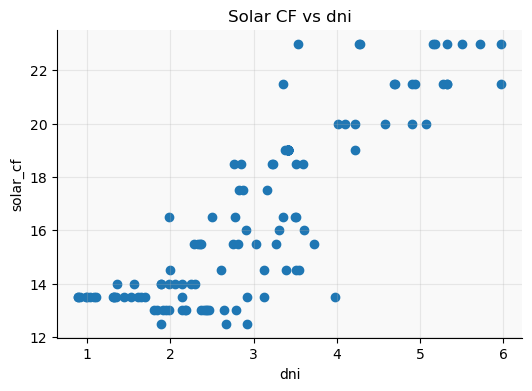

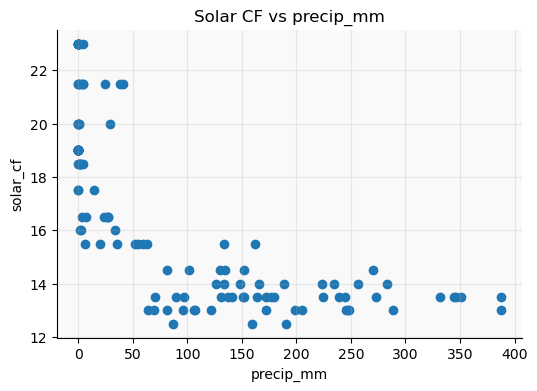

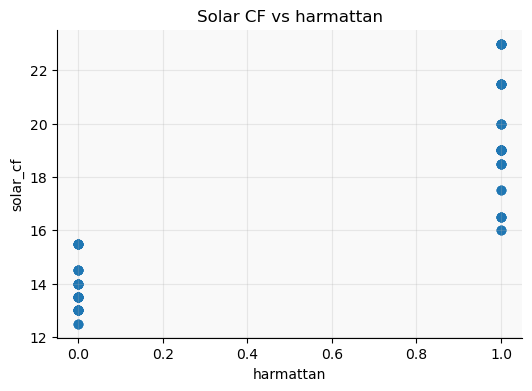

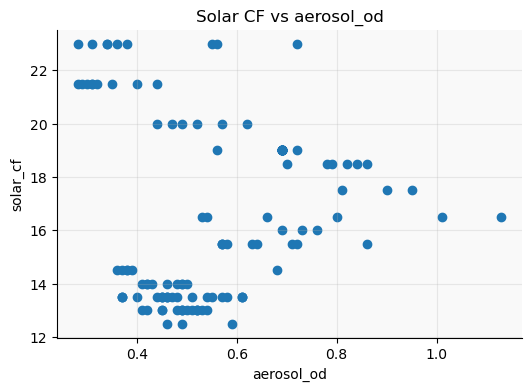

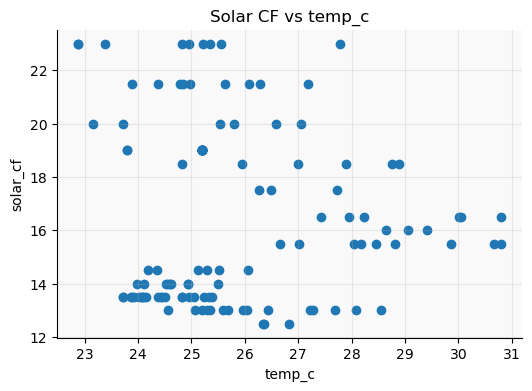

In [17]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4 — SCATTER PLOTS
# Solar CF vs Drivers
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

solar_vars = [
    'dni',
    'precip_mm',
    'harmattan',
    'aerosol_od',
    'temp_c'
]

for var in solar_vars:

    plt.figure(figsize=(6,4))

    plt.scatter(
        df[var],
        df['solar_cf']
    )

    plt.xlabel(var)
    plt.ylabel('solar_cf')
    plt.title(f'Solar CF vs {var}')

    plt.grid(True)

    plt.show()

In [22]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4A — ARDL LAG SELECTION
# ln_receivables
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

y = df["solar_cf"]

X = df[
    [
        "dni",
        "precip_mm",
        "harmattan",
        "aerosol_od",
        "temp_c"
    ]
]

sel_solar = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\nSELECTED ORDER")
print(sel_solar.model.ardl_order)

print("\nAR LAGS")
print(sel_solar.model.ar_lags)

print("\nDL LAGS")
print(sel_solar.model.dl_lags)


SELECTED ORDER
(4, 1, 4, 4)

AR LAGS
[1, 2, 3, 4]

DL LAGS
{'dni': [0, 1], 'harmattan': [0, 1, 2, 3, 4], 'temp_c': [0, 1, 2, 3, 4]}


month
1     19.545455
2     18.318182
3     16.818182
4     16.136364
5     13.954545
6     14.090909
7     14.500000
8     14.500000
9     14.909091
10    15.045455
11    21.045455
12    22.272727
Name: solar_cf, dtype: float64


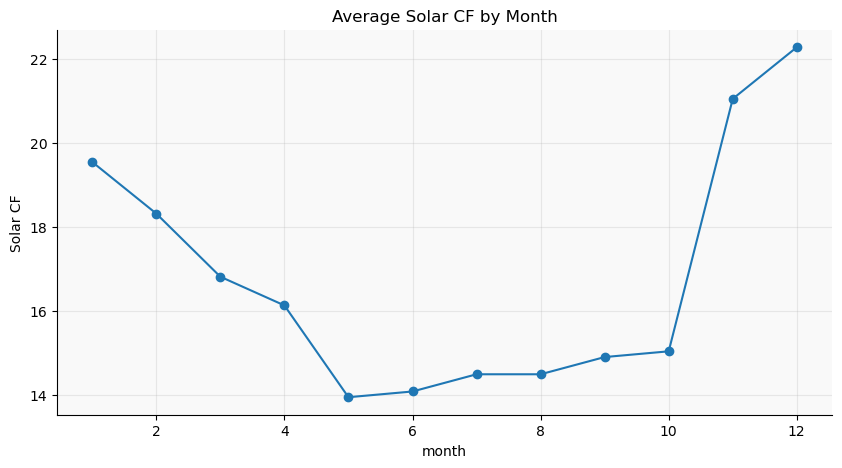

In [18]:
# ═══════════════════════════════════════════════════════════════════════
# MONTHLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════

df['month'] = df.index.month

monthly_cf = (
    df.groupby('month')['solar_cf']
      .mean()
)

print(monthly_cf)

monthly_cf.plot(
    marker='o',
    figsize=(10,5),
    title='Average Solar CF by Month'
)

plt.ylabel('Solar CF')
plt.grid(True)

plt.show()

quarter
1    18.227273
2    14.727273
3    14.636364
4    19.454545
Name: solar_cf, dtype: float64


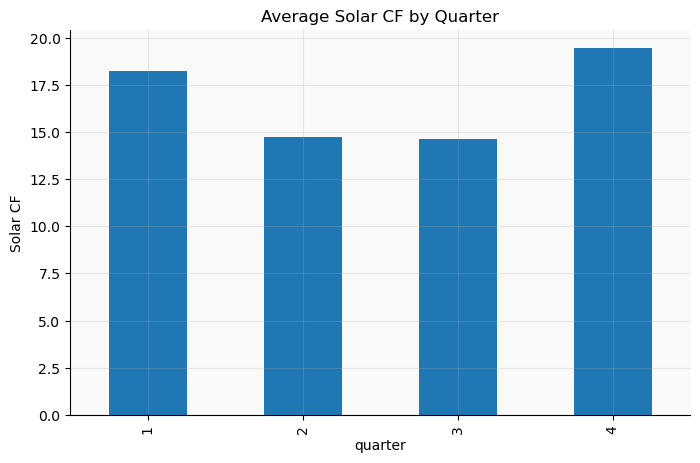

In [19]:
# ═══════════════════════════════════════════════════════════════════════
# QUARTERLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════

df['quarter'] = df.index.quarter

quarterly_cf = (
    df.groupby('quarter')['solar_cf']
      .mean()
)

print(quarterly_cf)

quarterly_cf.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Solar CF by Quarter'
)

plt.ylabel('Solar CF')

plt.grid(True)

plt.show()

In [20]:
# ═══════════════════════════════════════════════════════════════════════
# ANOVA TEST FOR MONTHLY SEASONALITY
# ═══════════════════════════════════════════════════════════════════════

from scipy.stats import f_oneway

monthly_groups = [
    group['solar_cf'].values
    for _, group in df.groupby(df.index.month)
]

f_stat, p_value = f_oneway(*monthly_groups)

print("\nANOVA RESULTS")
print("F-stat :", round(f_stat,4))
print("p-value:", round(p_value,6))


ANOVA RESULTS
F-stat : 28.9962
p-value: 0.0


In [23]:
solar_ardl = sel_solar.model.fit()

print(solar_ardl.summary())

                              ARDL Model Results                              
Dep. Variable:               solar_cf   No. Observations:                  132
Model:               ARDL(4, 1, 4, 4)   Log Likelihood                -111.396
Method:               Conditional MLE   S.D. of innovations              0.578
Date:                Sat, 06 Jun 2026   AIC                            258.793
Time:                        23:30:36   BIC                            310.129
Sample:                    05-01-2015   HQIC                           279.651
                         - 12-01-2025                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           28.0833      2.483     11.312      0.000      23.164      33.003
solar_cf.L1     -0.5531      0.084     -6.560      0.000      -0.720      -0.386
solar_cf.L2     -0.3235      0.068     -4.74

In [24]:
from statsmodels.tsa.ardl import UECM

solar_uecm = UECM.from_ardl(sel_solar.model)

solar_uecm_res = solar_uecm.fit()

print(solar_uecm_res.summary())

                              UECM Model Results                              
Dep. Variable:             D.solar_cf   No. Observations:                  132
Model:               UECM(4, 1, 4, 4)   Log Likelihood                -111.396
Method:               Conditional MLE   S.D. of innovations             16.977
Date:                Sat, 06 Jun 2026   AIC                            258.793
Time:                        23:49:22   BIC                            310.129
Sample:                    05-01-2015   HQIC                           279.651
                         - 12-01-2025                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             28.0833      2.483     11.312      0.000      23.164      33.003
solar_cf.L1       -2.1026      0.151    -13.931      0.000      -2.402      -1.803
dni.L1             0.7895      0.146

c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: precip_mm, aerosol_od.
  return _format_order(self.data.orig_exog, order, self._causal)


In [25]:
solar_bt = solar_uecm_res.bounds_test(case=3)

print(solar_bt)

BoundsTestResult
Stat: 69.22978
Upper P-value: 0
Lower P-value: 0
Null: No Cointegration
Alternative: Possible Cointegration



c:\Users\pc\miniconda3\envs\FE\Lib\site-packages\statsmodels\tsa\ardl\model.py:455: SpecificationWarning: exog contains variables that are missing from the order dictionary.  Missing keys: precip_mm, aerosol_od.
  return _format_order(self.data.orig_exog, order, self._causal)


In [26]:
month_dummies = pd.get_dummies(
    df.index.month,
    prefix="m",
    drop_first=True
)

In [28]:
# ═══════════════════════════════════════════════════════════════
# MONTHLY DUMMY BENCHMARK MODEL
# ═══════════════════════════════════════════════════════════════

import statsmodels.api as sm
import pandas as pd

month_dummies = pd.get_dummies(
    df.index.month,
    prefix='m',
    drop_first=True,
    dtype=float
)

# IMPORTANT
month_dummies.index = df.index

X = sm.add_constant(month_dummies)

seasonal_model = sm.OLS(
    df["solar_cf"],
    X
).fit()

print(seasonal_model.summary())

                            OLS Regression Results                            
Dep. Variable:               solar_cf   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     29.00
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           9.19e-29
Time:                        00:07:02   Log-Likelihood:                -256.43
No. Observations:                 132   AIC:                             536.9
Df Residuals:                     120   BIC:                             571.4
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.5455      0.534     36.611      0.0

In [29]:
print(solar_uecm_res.test_heteroskedasticity())

print(solar_uecm_res.test_normality())

       ARCH-LM       P-value  DF
Lag                             
1    65.522023  5.746818e-16   1
2    79.138326  6.536282e-18   2
3    78.902219  5.278234e-17   3
4    84.276859  2.159618e-17   4
5    85.501155  5.909954e-17   5
6    86.290694  1.783104e-16   6
7    86.338150  6.975075e-16   7
8    87.489958  1.501546e-15   8
9    87.805487  4.482849e-15   9
10   88.662526  9.859651e-15  10
Jarque-Bera    9.845178
P-value        0.007280
Skewness       0.383169
Kurtosis       1.878084
dtype: float64
